In [2]:
print("student performance predictor")

student performance predictor


In [3]:
import pandas 
import numpy
import sklearn

print("all libraries are working")

all libraries are working


# Student Performance Predictor

## Problem

We want to predict a student's exam score based on their academic and lifestyle features.

## Features (X)

- Study Hours
- Attendance
- Previous Marks
- Assignments Completed
- Sleep Hours

## Target (y)

- Exam Score

## Machine Learning Problem

Supervised Learning → Regression


In [6]:
import numpy as np
import pandas as pd

In [7]:
np.random.seed(42)

n_students = 500

study_hours = np.random.uniform(1, 10, n_students)
attendance = np.random.uniform(50, 100, n_students)
previous_marks = np.random.uniform(40, 95, n_students)
assignments_completed = np.random.randint(3, 11, n_students)
sleep_hours = np.random.uniform(4, 9, n_students)

In [8]:
noise = np.random.normal(0, 5, n_students)

exam_score = (
    0.30 * previous_marks
    + 0.25 * attendance
    + 2.5 * study_hours
    + 1.5 * assignments_completed
    + 1.0 * sleep_hours
    + noise
)

exam_score = np.clip(exam_score, 0, 100)

In [9]:
df = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "previous_marks": previous_marks,
    "assignments_completed": assignments_completed,
    "sleep_hours": sleep_hours,
    "exam_score": exam_score
})

In [10]:
df.head()

,study_hours,attendance,previous_marks,assignments_completed,sleep_hours,exam_score
0,4.370861,84.908086,50.182311,10,6.676551,73.761406
1,9.556429,76.804818,69.804552,4,5.076009,77.615122
2,7.587945,65.476381,88.012021,8,4.060604,78.751077
3,6.387926,90.689751,80.272369,6,5.206007,81.935202
4,2.404168,84.236559,84.360863,7,8.879369,58.241025


In [11]:
df.to_csv("../data/raw/student_data.csv", index=False)

In [12]:
df.shape

(500, 6)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            500 non-null    float64
 1   attendance             500 non-null    float64
 2   previous_marks         500 non-null    float64
 3   assignments_completed  500 non-null    int32  
 4   sleep_hours            500 non-null    float64
 5   exam_score             500 non-null    float64
dtypes: float64(5), int32(1)
memory usage: 21.6 KB


In [14]:
df.describe()

,study_hours,attendance,previous_marks,assignments_completed,sleep_hours,exam_score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.487055,74.097570,68.465697,6.532000,6.538983,69.040176
std,2.688196,14.274673,16.345611,2.196047,1.446919,11.414418
min,1.045554,50.231601,40.271699,3.000000,4.016091,33.307235
25%,3.171517,61.454962,53.267543,5.000000,5.270316,61.189625
50%,5.618474,73.591078,69.685608,7.000000,6.611938,68.855441
75%,7.805124,86.316841,82.753907,8.000000,7.809672,76.224020
max,9.936683,99.985884,94.967755,10.000000,8.991738,100.000000


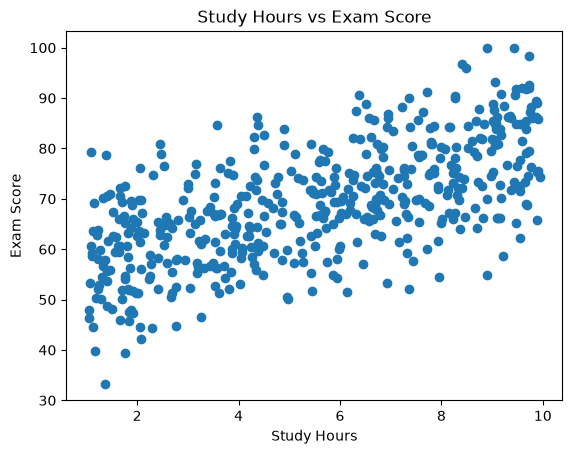

In [15]:
# Does studying more actually correspond to higher exam scores?
import matplotlib.pyplot as plt

plt.scatter(df["study_hours"], df["exam_score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.show()

In [16]:
df.corr(numeric_only=True)

,study_hours,attendance,previous_marks,assignments_completed,sleep_hours,exam_score
study_hours,1.000000,0.010354,0.053966,0.049923,-0.050631,0.642959
attendance,0.010354,1.000000,-0.025912,0.024688,-0.051334,0.309410
previous_marks,0.053966,-0.025912,1.000000,-0.013007,0.089258,0.473239
assignments_completed,0.049923,0.024688,-0.013007,1.000000,0.017224,0.344636
sleep_hours,-0.050631,-0.051334,0.089258,0.017224,1.000000,0.115689
exam_score,0.642959,0.309410,0.473239,0.344636,0.115689,1.000000


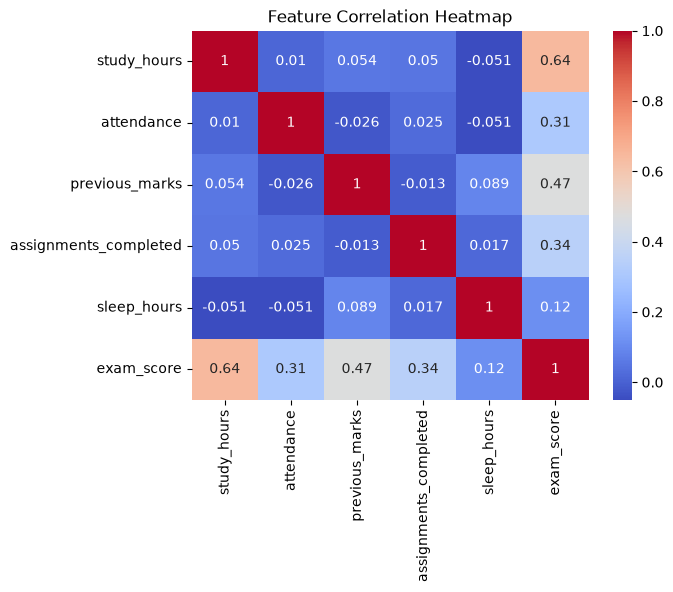

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [19]:
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

In [20]:
X.head()

,study_hours,attendance,previous_marks,assignments_completed,sleep_hours
0,4.370861,84.908086,50.182311,10,6.676551
1,9.556429,76.804818,69.804552,4,5.076009
2,7.587945,65.476381,88.012021,8,4.060604
3,6.387926,90.689751,80.272369,6,5.206007
4,2.404168,84.236559,84.360863,7,8.879369


In [21]:
y.head()

0    73.761406
1    77.615122
2    78.751077
3    81.935202
4    58.241025
Name: exam_score, dtype: float64

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (400, 5)
X_test : (100, 5)
y_train: (400,)
y_test : (100,)


In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [27]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[2.59,0.25,0.31,1.53,0.91]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['study_hours','attendance','previous_marks','assignments_completed', 'sleep_hours']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.5858
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [28]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [2.59239952 0.24912927 0.30670519 1.53480216 0.91114206]
Intercept: -0.5857632302807048


In [29]:
for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

study_hours : 2.5923995165401776
attendance : 0.2491292666011432
previous_marks : 0.3067051923445471
assignments_completed : 1.5348021614528862
sleep_hours : 0.9111420612717862


In [30]:
y_pred = model.predict(X_test)

In [31]:
y_pred[:10]

array([67.78354935, 74.79463016, 53.28527132, 58.90647981, 86.30121296,
       59.08508922, 63.91511647, 68.53041765, 61.41452502, 78.03383619])

In [32]:
# mean absolute error
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 3.8012132267837884


In [33]:
# MSE mean squared error 
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 25.556940425401816


In [34]:
#RMSE
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 5.055387267598974


In [36]:
#R^2
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.7846101367951547


In [37]:
print("Model Evaluation")
print("----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
----------------
MAE : 3.8012132267837884
MSE : 25.556940425401816
RMSE: 5.055387267598974
R²  : 0.7846101367951547


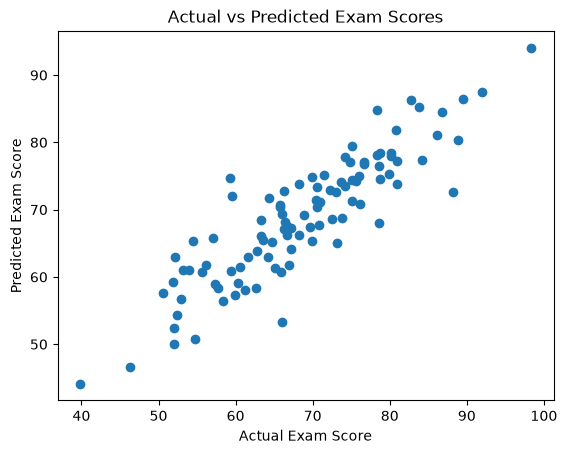

In [38]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")
plt.show()

In [39]:
import joblib

In [40]:
joblib.dump(model, "../models/student_performance_model.pkl")

['../models/student_performance_model.pkl']

In [41]:
sample_student = [[8, 85, 75, 8, 7]]

prediction = model.predict(sample_student)

print("Predicted Exam Score:", prediction[0])

Predicted Exam Score: 82.9887217095045


c:\Users\chdev\OneDrive\文件\AI-ML-Projects\student-performance-predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
